# 4Av6 — Beginner-Friendly Version of the Current 4Av5 Pipeline

This notebook performs the same core experiment as the current 4Av5:

- Four temperatures: 30, 40, 50, and 60 °C
- Direct absolute Savitzky–Golay-smoothed `Primary` and `dPrimary/dt` as ESN inputs
- No baseline centering, min–max normalization, or fitted ESN input scaler
- A fixed 0–3 s analysis window with no washout
- Nine trajectory summaries per reservoir unit
- 27 manually calculated thermal features plus `Temperature_C`
- Three fixed reservoir seeds
- Fourteen-fold leave-one-material-out validation
- Joint ESN–XGBoost optimization using Optuna TPE
- Experiment tracking using MLflow

The code is deliberately expanded into smaller steps and descriptive variables. The purpose is
to make the data flow easier to study without changing the scientific pipeline.

## 1. Imports and experiment settings

**Prerequisites:** installed Python packages and a project folder containing `data/`.

**Outputs:** experiment settings, input/output paths, and MLflow locations used by later sections.

In [87]:
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
from scipy import linalg
from scipy.signal import savgol_filter
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)


In [88]:
TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
TARGET = "eff"
ANALYSIS_WINDOW = (0.0, 3.0)

THERMAL_WINDOWS = {
    "early": (0.0, 1.0),
    "mid": (1.0, 2.0),
    "late": (2.0, 3.0),
}

RESERVOIR_SEEDS = (42, 43, 44)

N_TRIALS = 250
N_STARTUP_TRIALS = 20
OPTUNA_SEED = 4042
USE_MULTIVARIATE_TPE = True
STABILITY_WEIGHT = 0.25
WASHOUT = 0

current_working_directory = Path.cwd().resolve()

if (current_working_directory / "data").is_dir():
    PROJECT_ROOT = current_working_directory
else:
    PROJECT_ROOT = current_working_directory.parent

DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"

RESULTS_DIR = PROJECT_ROOT / "results" / "multi_temp_esn"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

temperature_tag = "-".join(TEMPERATURE_FOLDERS)
RESULT_STEM = (
    f"{temperature_tag}_{TARGET}_4av6_beginner_primary_dprimary_absolute_smoothed_"
    "0to3_summarized_esn_thermal_optuna_tpe_mlflow"
)

CHECKPOINT_FILE = RESULTS_DIR / f"{RESULT_STEM}_trial_checkpoint.csv"
PARAMETER_FILE = RESULTS_DIR / f"{RESULT_STEM}_parameters.json"

MLFLOW_DB_FILE = RESULTS_DIR / "4Av6_beginner_mlflow_tracking.db"
MLFLOW_ARTIFACT_DIR = RESULTS_DIR / "4av6_beginner_mlflow_artifacts"
MLFLOW_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

absolute_mlflow_database_path = MLFLOW_DB_FILE.resolve()
MLFLOW_TRACKING_URI = f"sqlite:///{absolute_mlflow_database_path}"
MLFLOW_EXPERIMENT = "4Av6_beginner_primary_dprimary_summarized_esn_thermal"
MLFLOW_RUN_NAME = datetime.now(timezone.utc).strftime("4Av6_%Y%m%dT%H%M%SZ")

print("Current working directory:", current_working_directory)
print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)
print("Results directory:", RESULTS_DIR)
print("Optuna trials:", N_TRIALS)


Current working directory: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/notebooks
Project root: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection
Data root: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/data/02_preprocessed
Results directory: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/multi_temp_esn
Optuna trials: 250


## 2. Load trials and assign standard material properties

**Prerequisites:** `DATA_ROOT`, `TEMPERATURE_FOLDERS`, the standard-property table, and aliases.

**Output:** `DATA`, a single sample-level table containing all CSV rows. One experimental trial
still occupies many rows because it contains many timestamps.

In [89]:
SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood", "pdms": "pdms", "gypsum": "gypsum", "cement": "cement",
    "graphite": "graphite", "carbon": "graphite",
    "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

loaded_frames = []
file_loading_records = []

for temperature in TEMPERATURE_FOLDERS:
    temperature_folder = DATA_ROOT / temperature
    csv_paths = sorted(temperature_folder.glob("*.csv"))

    for csv_path in csv_paths:
        current_frame = pd.read_csv(csv_path)
        current_frame["Temperature"] = temperature
        current_frame["source_file"] = csv_path.name
        loaded_frames.append(current_frame)

        loading_record = {"Temperature": temperature,"file": csv_path.name,"rows_loaded": len(current_frame),}
        file_loading_records.append(loading_record)

DATA = pd.concat(loaded_frames, ignore_index=True)
DATA = DATA.replace([np.inf, -np.inf], np.nan)

DATA["Trial"] = pd.to_numeric(DATA["Trial"])
DATA["Time"] = pd.to_numeric(DATA["Time"])
DATA["Primary"] = pd.to_numeric(DATA["Primary"])
DATA["Secondary"] = pd.to_numeric(DATA["Secondary"])
DATA["Trial"] = DATA["Trial"].astype(int)

temperature_text = DATA["Temperature"]
extracted_temperature_text = temperature_text.str.extract(
    r"(\d+(?:\.\d+)?)",
    expand=False
)                                                                                                           #review
DATA["Temperature_C"] = pd.to_numeric(extracted_temperature_text)

DATA["Sample"] = DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ").map(SAMPLE_ALIASES)

In [90]:
STANDARD_PROPERTIES = {
    "ps_foam":  {"k": 0.034, "Mass": 1.0, "Volume": 1.0, "rho": 25.0,   "cp": 1400.0},
    "pu_foam":  {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 30.0,   "cp": 1400.0},
    "cork":     {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 240.0,  "cp": 1800.0},
    "wood":     {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 700.0,  "cp": 1700.0},
    "pdms":     {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 970.0,  "cp": 1460.0},
    "gypsum":   {"k": 0.170, "Mass": 1.0, "Volume": 1.0, "rho": 800.0,  "cp": 1090.0},
    "cement":   {"k": 0.290, "Mass": 1.0, "Volume": 1.0, "rho": 1440.0, "cp": 750.0},
    "graphite": {"k": 100.0, "Mass": 1.0, "Volume": 1.0, "rho": 1820.0, "cp": 710.0},
    "bismuth":  {"k": 8.1,   "Mass": 1.0, "Volume": 1.0, "rho": 9780.0, "cp": 130.0},
    "titanium": {"k": 21.9,  "Mass": 1.0, "Volume": 1.0, "rho": 4506.0, "cp": 523.0},
    "nickel":   {"k": 90.9,  "Mass": 1.0, "Volume": 1.0, "rho": 8908.0, "cp": 461.0},
    "iron":     {"k": 80.4,  "Mass": 1.0, "Volume": 1.0, "rho": 7874.0, "cp": 449.0},
    "aluminum": {"k": 237.0, "Mass": 1.0, "Volume": 1.0, "rho": 2700.0, "cp": 897.0},
    "copper":   {"k": 401.0, "Mass": 1.0, "Volume": 1.0, "rho": 8960.0, "cp": 385.0},
}

variables = ("k", "Mass", "Volume", "rho", "cp")

for var in variables:
    property_values = {}

    for material, properties in STANDARD_PROPERTIES.items():
        property_values[material] = properties[var]
        
    DATA[var] = DATA["Sample"].map(property_values)

DATA["trial_id"] = (
    DATA["Temperature"]
    + "__"
    + DATA["Sample"]
    + "_trial_"
    + DATA["Trial"].astype(str)
)

DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])

DATA = DATA.sort_values(["Temperature", "trial_id", "Time"])
DATA = DATA.reset_index(drop=True)

print("Rows:", len(DATA))
print("Temperature-specific trials:", DATA["trial_id"].nunique())
print("Materials:", DATA["Sample"].nunique())
display(pd.DataFrame(file_loading_records).head())
display(DATA.head())

Rows: 70480
Temperature-specific trials: 336
Materials: 14


,Temperature,file,rows_loaded
0,30C,al_1.csv,223
1,30C,al_2.csv,203
2,30C,al_3.csv,193
3,30C,al_4.csv,210
4,30C,al_5.csv,193


,index,Sample,Trial,k,Mass,Volume,rho,cp,Time,Primary,Secondary,Temperature,source_file,Temperature_C,trial_id,eff
0,0,aluminum,1,237.0,1.0,1.0,2700.0,897.0,0.00941,0.000659,0.0007,30C,al_1.csv,30,30C__aluminum_trial_1,23958.094665
1,1,aluminum,1,237.0,1.0,1.0,2700.0,897.0,0.10066,0.000660,0.0007,30C,al_1.csv,30,30C__aluminum_trial_1,23958.094665
2,2,aluminum,1,237.0,1.0,1.0,2700.0,897.0,0.20066,0.000660,0.0007,30C,al_1.csv,30,30C__aluminum_trial_1,23958.094665
3,3,aluminum,1,237.0,1.0,1.0,2700.0,897.0,0.30066,0.000660,0.0007,30C,al_1.csv,30,30C__aluminum_trial_1,23958.094665
4,4,aluminum,1,237.0,1.0,1.0,2700.0,897.0,0.40070,0.000660,0.0007,30C,al_1.csv,30,30C__aluminum_trial_1,23958.094665


## 3. Detect contact and align the 0–3 s analysis window

**Prerequisite:** sample-level `DATA` from Section 2.

**Outputs:**

- `ALIGNED_TRIALS`: dictionary containing one 0–3 s time-series DataFrame per trial.
- `ALIGNMENT`: one summary row per retained trial.

In [ ]:
def find_contact_time(
    trial,
    smooth_window=15,
    polynomial_order=2,
    threshold_fraction=0.30,
    skipped_samples=5,
):
    """Estimate contact onset from the strongest negative Primary-signal transition."""

    contact_data = trial[["Time", "Primary"]].copy()
    #contact_data["Time"] = pd.to_numeric(contact_data["Time"], errors="coerce")                ##redundant
    #contact_data["Primary"] = pd.to_numeric(contact_data["Primary"], errors="coerce")          ##redundant
    #contact_data = contact_data.dropna()                                                       ##redundant
    contact_data = contact_data.sort_values("Time")
    #contact_data = contact_data.drop_duplicates("Time")                                        ##redundant
    contact_data = contact_data.reset_index(drop=True)

    all_times = contact_data["Time"].to_numpy(float)
    all_primary_values = contact_data["Primary"].to_numpy(float)

    working_times = all_times[skipped_samples:]
    working_primary_values = all_primary_values[skipped_samples:]

    selected_window = min(int(smooth_window), len(working_primary_values))
    if selected_window % 2 == 0:
        selected_window = selected_window - 1

    smoothed_primary = savgol_filter(
        working_primary_values,
        selected_window,
        polynomial_order,
        mode="interp",
    )
    primary_derivative = np.gradient(smoothed_primary, working_times)

    strongest_drop_position = int(np.argmin(primary_derivative))
    strongest_drop_value = primary_derivative[strongest_drop_position]
    derivative_threshold = threshold_fraction * strongest_drop_value
    strongly_decreasing = primary_derivative < derivative_threshold

    contact_position = 0
    for position in range(strongest_drop_position, -1, -1):
        if not strongly_decreasing[position]:
            contact_position = position + 1
            break

    detected_contact_time = float(working_times[contact_position])
    return detected_contact_time

In [92]:
ALIGNED_TRIALS = {}
alignment_records = []

for trial_id, trial_data in DATA.groupby("trial_id", sort=False):                       ##review
    trial_data = trial_data.sort_values("Time")
    #trial_data = trial_data.drop_duplicates("Time")
    #trial_data = trial_data.copy()



    contact_time = find_contact_time(trial_data)



    trial_data["time_from_contact"] = trial_data["Time"] - contact_time

    analysis_start = ANALYSIS_WINDOW[0]
    analysis_end = ANALYSIS_WINDOW[1]
    inside_analysis_window = trial_data["time_from_contact"].between(
        analysis_start, analysis_end, inclusive="both"
    )
    trial_data = trial_data[inside_analysis_window].copy()

    ALIGNED_TRIALS[trial_id] = trial_data.reset_index(drop=True)

    alignment_record = {
        "trial_id": trial_id,
        "Temperature": trial_data["Temperature"].iloc[0],
        "Temperature_C": float(trial_data["Temperature_C"].iloc[0]),
        "Sample": trial_data["Sample"].iloc[0],
        "Trial": int(trial_data["Trial"].iloc[0]),
        "contact_time": contact_time,
        "n_analysis_samples": len(trial_data),
    }
    alignment_records.append(alignment_record)

ALIGNMENT = pd.DataFrame(alignment_records)

print("Aligned trials retained:", len(ALIGNED_TRIALS))
display(ALIGNMENT.head())


Aligned trials retained: 336


,trial_id,Temperature,Temperature_C,Sample,Trial,contact_time,n_analysis_samples
0,30C__aluminum_trial_1,30C,30.0,aluminum,1,8.40066,30
1,30C__aluminum_trial_2,30C,30.0,aluminum,2,7.40070,30
2,30C__aluminum_trial_3,30C,30.0,aluminum,3,7.70070,31
3,30C__aluminum_trial_4,30C,30.0,aluminum,4,8.70070,31
4,30C__aluminum_trial_5,30C,30.0,aluminum,5,7.20070,31


## 4. Calculate the 27 scalar thermal-response features

**Prerequisites:** `ALIGNED_TRIALS` and `THERMAL_WINDOWS`.

**Output:** `THERMAL_FEATURES`, where every row represents one complete trial rather than one
timestamp. The table contains 27 thermal features plus identifying columns and targets.

In [25]:
def smooth_signal(values, window=11, polynomial_order=2):
    """Smooth one signal while preserving its number of samples."""
    numeric_values = np.asarray(values, float)
    selected_window = min(int(window), len(numeric_values))

    if selected_window % 2 == 0:
        selected_window = selected_window - 1

    minimum_window = polynomial_order + 2
    if minimum_window % 2 == 0:
        minimum_window = minimum_window + 1

    smoothed_values = savgol_filter(
        numeric_values,
        selected_window,
        polynomial_order,
        mode="interp",
    )
    return smoothed_values

def calculate_window_slope(time_values, signal_values, time_window):
    """Fit a straight line within one declared time interval and return its slope."""
    window_start = time_window[0]
    window_end = time_window[1]
    inside_window = (time_values >= window_start) & (time_values <= window_end)

    selected_times = time_values[inside_window]
    selected_signal = signal_values[inside_window]
    fitted_coefficients = np.polyfit(selected_times, selected_signal, 1)
    fitted_slope = fitted_coefficients[0]
    return float(fitted_slope)

def calculate_thermal_features(trial_data):
    """Convert one aligned time-series trial into 27 scalar thermal features."""
    time_values = trial_data["time_from_contact"].to_numpy(float)
    primary_values = trial_data["Primary"].to_numpy(float)
    secondary_values = trial_data["Secondary"].to_numpy(float)

    smoothed_primary = smooth_signal(primary_values)
    smoothed_secondary = smooth_signal(secondary_values)
    primary_minus_secondary = smoothed_primary - smoothed_secondary

    named_signals = {
        "primary": smoothed_primary,
        "secondary": smoothed_secondary,
        "difference": primary_minus_secondary,
    }

    calculated_features = {}

    for signal_name, signal_values in named_signals.items():
        initial_value = signal_values[0]
        change_from_initial = signal_values - initial_value
        signal_rate = np.gradient(signal_values, time_values)

        calculated_features[f"{signal_name}_final_change"] = float(
            change_from_initial[-1]
        )
        calculated_features[f"{signal_name}_max_abs_change"] = float(
            np.max(np.abs(change_from_initial))
        )
        calculated_features[f"{signal_name}_response_auc"] = float(
            np.trapezoid(np.abs(change_from_initial), time_values)
        )

        early_slope = calculate_window_slope(
            time_values, signal_values, THERMAL_WINDOWS["early"]
        )
        mid_slope = calculate_window_slope(
            time_values, signal_values, THERMAL_WINDOWS["mid"]
        )
        late_slope = calculate_window_slope(
            time_values, signal_values, THERMAL_WINDOWS["late"]
        )

        calculated_features[f"{signal_name}_early_slope"] = early_slope
        calculated_features[f"{signal_name}_mid_slope"] = mid_slope
        calculated_features[f"{signal_name}_late_slope"] = late_slope
        calculated_features[f"{signal_name}_max_abs_rate"] = float(
            np.max(np.abs(signal_rate))
        )
        calculated_features[f"{signal_name}_rate_auc"] = float(
            np.trapezoid(np.abs(signal_rate), time_values)
        )

    primary_auc = calculated_features["primary_response_auc"]
    secondary_auc = calculated_features["secondary_response_auc"]

    calculated_features["secondary_primary_auc_ratio"] = secondary_auc / primary_auc

    calculated_features["initial_sensor_difference"] = float(
        primary_minus_secondary[0]
    )
    calculated_features["final_sensor_difference"] = float(
        primary_minus_secondary[-1]
    )

    return calculated_features


In [26]:
thermal_feature_records = []

for trial_id, trial_data in ALIGNED_TRIALS.items():
    one_trial_features = calculate_thermal_features(trial_data)

    one_trial_features["trial_id"] = trial_id
    one_trial_features["Temperature"] = trial_data["Temperature"].iloc[0]
    one_trial_features["Temperature_C"] = float(trial_data["Temperature_C"].iloc[0])
    one_trial_features["Sample"] = trial_data["Sample"].iloc[0]
    one_trial_features["Trial"] = int(trial_data["Trial"].iloc[0])
    one_trial_features["k"] = float(trial_data["k"].iloc[0])
    one_trial_features["eff"] = float(trial_data["eff"].iloc[0])

    thermal_feature_records.append(one_trial_features)

THERMAL_FEATURES = pd.DataFrame(thermal_feature_records)

ID_COLUMNS = [
    "trial_id", "Temperature", "Temperature_C", "Sample", "Trial", "k", "eff"
]

THERMAL_COLUMNS = []
for column_name in THERMAL_FEATURES.columns:
    if column_name not in ID_COLUMNS:
        THERMAL_COLUMNS.append(column_name)

print("Trial-level rows:", len(THERMAL_FEATURES))
print("Thermal features per trial:", len(THERMAL_COLUMNS))
display(THERMAL_FEATURES.head())


Trial-level rows: 336
Thermal features per trial: 27


,primary_final_change,primary_max_abs_change,primary_response_auc,primary_early_slope,primary_mid_slope,primary_late_slope,primary_max_abs_rate,primary_rate_auc,secondary_final_change,secondary_max_abs_change,...,secondary_primary_auc_ratio,initial_sensor_difference,final_sensor_difference,trial_id,Temperature,Temperature_C,Sample,Trial,k,eff
0,-0.000003,0.000003,0.000007,-0.000002,-5.608193e-07,-2.301865e-07,0.000003,0.000003,-7.393007e-07,7.393007e-07,...,0.108039,-0.000040,-0.000043,30C__aluminum_trial_1,30C,30.0,aluminum,1,237.0,23958.094665
1,-0.000003,0.000003,0.000007,-0.000002,-5.356806e-07,-2.233930e-07,0.000004,0.000003,-7.777622e-07,7.777622e-07,...,0.126702,-0.000040,-0.000043,30C__aluminum_trial_2,30C,30.0,aluminum,2,237.0,23958.094665
2,-0.000003,0.000003,0.000007,-0.000002,-4.910211e-07,-2.395687e-07,0.000003,0.000003,-8.261538e-07,8.261538e-07,...,0.137653,-0.000040,-0.000043,30C__aluminum_trial_3,30C,30.0,aluminum,3,237.0,23958.094665
3,-0.000003,0.000003,0.000007,-0.000002,-5.429477e-07,-2.277291e-07,0.000003,0.000003,-7.784615e-07,7.784615e-07,...,0.130203,-0.000040,-0.000043,30C__aluminum_trial_4,30C,30.0,aluminum,4,237.0,23958.094665
4,-0.000003,0.000003,0.000007,-0.000002,-5.403697e-07,-2.391434e-07,0.000003,0.000003,-8.559441e-07,8.559441e-07,...,0.151386,-0.000041,-0.000043,30C__aluminum_trial_5,30C,30.0,aluminum,5,237.0,23958.094665


## 5. Run the Echo State Network and summarize its trajectories

**Prerequisites:** one aligned trial and one ESN hyperparameter candidate.

**Outputs:** two ESN input channels, a time × reservoir-unit state matrix, and nine scalar
summaries per reservoir unit.

In [27]:
class Reservoir:
    def __init__(
        self,
        res_size,
        leak_rate,
        input_magnitude,
        spectral_radius,
        washout,
        seed,
    ):
        self.res_size = int(res_size)
        self.leak_rate = float(leak_rate)
        self.input_magnitude = float(input_magnitude)
        self.spectral_radius = float(spectral_radius)
        self.washout = int(washout)

        random_generator = np.random.default_rng(seed)

        input_weight_shape = (self.res_size, 3)
        random_input_weights = random_generator.random(input_weight_shape) - 0.5
        self.Win = random_input_weights * self.input_magnitude

        recurrent_shape = (self.res_size, self.res_size)
        raw_recurrent_weights = random_generator.random(recurrent_shape) - 0.5
        raw_eigenvalues = linalg.eigvals(raw_recurrent_weights)
        raw_spectral_radius = np.max(np.abs(raw_eigenvalues))

        normalized_recurrent_weights = raw_recurrent_weights / raw_spectral_radius
        self.W = normalized_recurrent_weights * self.spectral_radius

    def run(self, input_sequence):
        input_sequence = np.asarray(input_sequence, float)

        current_state = np.zeros((self.res_size, 1))
        saved_states = []

        for input_row in input_sequence:
            input_column = input_row.reshape(-1, 1)
            bias_plus_input = np.vstack((1.0, input_column))
            input_drive = self.Win @ bias_plus_input
            recurrent_drive = self.W @ current_state
            proposed_state = np.tanh(input_drive + recurrent_drive)

            previous_state_contribution = (1 - self.leak_rate) * current_state
            proposed_state_contribution = self.leak_rate * proposed_state
            current_state = previous_state_contribution + proposed_state_contribution

            saved_states.append(current_state[:, 0].copy())

        state_matrix = np.asarray(saved_states)
        retained_state_matrix = state_matrix[self.washout:]
        return retained_state_matrix


In [28]:
def create_esn_input(trial_data):
    """Create the exact current-4Av5 ESN input: absolute smoothed P and dP/dt."""
    time_values = trial_data["time_from_contact"].to_numpy(float)
    raw_primary = trial_data["Primary"].to_numpy(float)
    smoothed_primary = smooth_signal(raw_primary)
    primary_derivative = np.gradient(smoothed_primary, time_values)

    input_sequence = np.column_stack((smoothed_primary, primary_derivative))
    return input_sequence

SUMMARY_NAMES = (
    "mean", "std", "min", "max", "initial",
    "net_change", "slope", "mean_abs", "abs_auc",
)

def summarize_reservoir_states(state_times, state_matrix):
    """Convert every unit's complete retained trajectory into nine scalar values."""
    state_times = np.asarray(state_times, float)
    state_matrix = np.asarray(state_matrix, float)

    summarized_features = {}
    number_of_units = state_matrix.shape[1]

    for unit_index in range(number_of_units):
        unit_trajectory = state_matrix[:, unit_index]

        unit_summaries = {
            "mean": float(np.mean(unit_trajectory)),
            "std": float(np.std(unit_trajectory, ddof=0)),
            "min": float(np.min(unit_trajectory)),
            "max": float(np.max(unit_trajectory)),
            "initial": float(unit_trajectory[0]),
            "net_change": float(unit_trajectory[-1] - unit_trajectory[0]),
            "slope": float(np.polyfit(state_times, unit_trajectory, 1)[0]),
            "mean_abs": float(np.mean(np.abs(unit_trajectory))),
            "abs_auc": float(np.trapezoid(np.abs(unit_trajectory), state_times)),
        }

        for summary_name, summary_value in unit_summaries.items():
            feature_name = f"esn_{summary_name}_u{unit_index:03d}"
            summarized_features[feature_name] = summary_value

    return summarized_features

audit_trial_id = next(iter(ALIGNED_TRIALS))
audit_trial = ALIGNED_TRIALS[audit_trial_id]
audit_input = create_esn_input(audit_trial)

print("ESN input audit passed:", audit_trial_id)
print("Input shape (timesteps, channels):", audit_input.shape)


ESN input audit passed: 30C__aluminum_trial_1
Input shape (timesteps, channels): (30, 2)


## 6. Metrics and XGBoost construction

The pooled metrics evaluate all out-of-fold predictions together. A single LOMO fold contains
only one material and therefore one fixed target; its NRMSE uses the training-material target
range instead of the constant test-target range.

In [29]:
def calculate_pooled_metrics(true_values, predicted_values):
    true_values = np.asarray(true_values, float)
    predicted_values = np.asarray(predicted_values, float)

    target_range = float(np.ptp(true_values))
    rmse = float(np.sqrt(mean_squared_error(true_values, predicted_values)))

    metrics = {
        "n": len(true_values),
        "mae": float(mean_absolute_error(true_values, predicted_values)),
        "rmse": rmse,
        "nrmse_range": rmse / target_range,
        "r2": float(r2_score(true_values, predicted_values)),
        "median_ape_pct": float(
            np.median(np.abs((true_values - predicted_values) / true_values)) * 100
        ),
    }
    return metrics

def calculate_single_material_fold_metrics(
    true_values,
    predicted_values,
    training_target_range,
):
    true_values = np.asarray(true_values, float)
    predicted_values = np.asarray(predicted_values, float)
    residuals = predicted_values - true_values
    rmse = float(np.sqrt(np.mean(residuals ** 2)))

    metrics = {
        "n": len(true_values),
        "mae": float(np.mean(np.abs(residuals))),
        "rmse": rmse,
        "nrmse_training_range": rmse / float(training_target_range),
        "mean_error_bias": float(np.mean(residuals)),
        "median_ape_pct": float(
            np.median(np.abs(residuals / true_values)) * 100
        ),
    }
    return metrics

def calculate_prediction_consistency_by_material(predictions):
    """Measure how much repeated LOMO predictions vary for each material."""
    consistency_rows = []

    for material_name, material_predictions in predictions.groupby(
        "Sample", sort=True
    ):
        actual_values = material_predictions["y_true"].to_numpy(float)
        predicted_values = material_predictions["y_pred"].to_numpy(float)

        actual_value = float(np.mean(actual_values))
        number_of_predictions = len(predicted_values)
        mean_prediction = float(np.mean(predicted_values))

        prediction_variance = float(np.var(predicted_values, ddof=1))

        prediction_standard_deviation = float(np.sqrt(prediction_variance))

        prediction_coefficient_of_variation = (
            prediction_standard_deviation / abs(mean_prediction)
        )

        consistency_row = {
            "material": material_name,
            "n_predictions": number_of_predictions,
            "actual": actual_value,
            "mean_prediction": mean_prediction,
            "prediction_variance": prediction_variance,
            "prediction_std": prediction_standard_deviation,
            "variance_over_actual_squared": (
                prediction_variance / (actual_value ** 2)
            ),
            "std_over_actual": (
                prediction_standard_deviation / abs(actual_value)
            ),
            "std_over_actual_pct": (
                100.0 * prediction_standard_deviation / abs(actual_value)
            ),
            "prediction_cv_abs_mean": prediction_coefficient_of_variation,
            "mean_error_bias": mean_prediction - actual_value,
            "mean_relative_error_pct": (
                100.0 * (mean_prediction - actual_value) / actual_value
            ),
        }
        consistency_rows.append(consistency_row)

    return pd.DataFrame(consistency_rows)

def create_regression_model(xgb_parameters, random_seed):
    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=int(random_seed),
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
        **xgb_parameters,
    )

    processing_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", xgb_model),
    ])

    complete_model = TransformedTargetRegressor(
        regressor=processing_pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )
    return complete_model


## 7. Build one trial-level ESN feature table

Each aligned trial is passed through one reservoir. Its time × unit state matrix is summarized,
producing one row per trial. The 27 thermal features are joined later during each LOMO fold.

In [30]:
def build_esn_feature_table(trial_ids, esn_parameters, reservoir_seed):
    reservoir = Reservoir(
        res_size=esn_parameters["res_size"],
        leak_rate=esn_parameters["leak_rate"],
        input_magnitude=esn_parameters["input_magnitude"],
        spectral_radius=esn_parameters["spectral_radius"],
        washout=WASHOUT,
        seed=reservoir_seed,
    )

    trial_feature_records = []

    for trial_id in trial_ids:
        trial_data = ALIGNED_TRIALS[trial_id]
        input_sequence = create_esn_input(trial_data)
        state_matrix = reservoir.run(input_sequence)

        all_trial_times = trial_data["time_from_contact"].to_numpy(float)
        retained_state_times = all_trial_times[WASHOUT:]
        summarized_states = summarize_reservoir_states(
            retained_state_times,
            state_matrix,
        )

        summarized_states["trial_id"] = trial_id
        summarized_states["Temperature"] = trial_data["Temperature"].iloc[0]
        summarized_states["Temperature_C"] = float(
            trial_data["Temperature_C"].iloc[0]
        )
        summarized_states["Sample"] = trial_data["Sample"].iloc[0]
        summarized_states["Trial"] = int(trial_data["Trial"].iloc[0])
        summarized_states["k"] = float(trial_data["k"].iloc[0])
        summarized_states["eff"] = float(trial_data["eff"].iloc[0])

        trial_feature_records.append(summarized_states)

    esn_feature_table = pd.DataFrame(trial_feature_records)
    return esn_feature_table


## 8. Evaluate one shared ESN–XGBoost candidate using 14-fold LOMO

**Candidate:** one complete set of ESN and XGBoost hyperparameters.

**LOMO:** each fold trains on 13 materials and predicts every trial belonging to the excluded
14th material. The same candidate is used in every fold.

In [31]:
ESN_SEARCH_SPACE = {
    "res_size": ("integer", 10, 30),
    "leak_rate": ("float", 0.10, 0.70),
    "input_magnitude": ("float", 0.25, 2.00),
    "spectral_radius": ("float", 0.70, 1.20),
}

XGB_SEARCH_SPACE = {
    "n_estimators": ("integer", 200, 1200),
    "max_depth": ("integer", 2, 6),
    "learning_rate": ("log_float", 0.015, 0.20),
    "min_child_weight": ("log_float", 0.10, 10.0),
    "subsample": ("float", 0.65, 1.00),
    "colsample_bytree": ("float", 0.40, 1.00),
    "reg_alpha": ("log_float", 1e-6, 3.0),
    "reg_lambda": ("log_float", 0.01, 30.0),
}

def separate_candidate_parameters(all_parameters):
    esn_parameters = {}
    for parameter_name in ESN_SEARCH_SPACE:
        esn_parameters[parameter_name] = all_parameters[parameter_name]

    xgb_parameters = {}
    for parameter_name in XGB_SEARCH_SPACE:
        xgb_parameters[parameter_name] = all_parameters[parameter_name]

    esn_parameters["res_size"] = int(esn_parameters["res_size"])
    xgb_parameters["n_estimators"] = int(xgb_parameters["n_estimators"])
    xgb_parameters["max_depth"] = int(xgb_parameters["max_depth"])
    return esn_parameters, xgb_parameters


In [32]:
def predict_one_lomo_fold(
    training_metadata,
    validation_metadata,
    all_candidate_parameters,
):
    training_trial_ids = training_metadata["trial_id"].tolist()
    validation_trial_ids = validation_metadata["trial_id"].tolist()

    esn_parameters, xgb_parameters = separate_candidate_parameters(
        all_candidate_parameters
    )

    all_fold_trial_ids = training_trial_ids + validation_trial_ids
    predictions_from_each_seed = []

    for reservoir_seed in RESERVOIR_SEEDS:
        esn_features = build_esn_feature_table(
            all_fold_trial_ids,
            esn_parameters,
            reservoir_seed,
        )
        esn_features = esn_features.set_index("trial_id")

        thermal_features_indexed = THERMAL_FEATURES.set_index("trial_id")
        selected_thermal_features = thermal_features_indexed[THERMAL_COLUMNS]
        combined_features = esn_features.join(
            selected_thermal_features,
            how="left",
        )

        esn_columns = []
        for column_name in combined_features.columns:
            if column_name.startswith("esn_"):
                esn_columns.append(column_name)

        regressor_columns = ["Temperature_C"]
        regressor_columns.extend(esn_columns)
        regressor_columns.extend(THERMAL_COLUMNS)

        X_train = combined_features.loc[training_trial_ids, regressor_columns]
        X_validation = combined_features.loc[validation_trial_ids, regressor_columns]
        y_train = combined_features.loc[training_trial_ids, TARGET]

        regression_model = create_regression_model(
            xgb_parameters,
            reservoir_seed,
        )
        regression_model.fit(X_train, y_train)
        seed_prediction = regression_model.predict(X_validation)

        minimum_training_target = y_train.min()
        maximum_training_target = y_train.max()
        seed_prediction = np.clip(
            seed_prediction,
            minimum_training_target,
            maximum_training_target,
        )
        predictions_from_each_seed.append(seed_prediction)

    averaged_prediction = np.mean(predictions_from_each_seed, axis=0)
    true_values = validation_metadata[TARGET].to_numpy(float)
    return true_values, averaged_prediction


In [33]:
def evaluate_candidate(metadata, all_candidate_parameters):
    lomo_splitter = LeaveOneGroupOut()
    material_groups = metadata["Sample"]

    fold_records = []
    prediction_tables = []

    split_iterator = lomo_splitter.split(metadata, groups=material_groups)

    for fold_number, split_indices in enumerate(split_iterator, start=1):
        training_indices, validation_indices = split_indices
        training_metadata = metadata.iloc[training_indices].reset_index(drop=True)
        validation_metadata = metadata.iloc[validation_indices].reset_index(drop=True)
        held_out_material = validation_metadata["Sample"].iloc[0]

        true_values, predicted_values = predict_one_lomo_fold(
            training_metadata,
            validation_metadata,
            all_candidate_parameters,
        )

        training_target_range = np.ptp(training_metadata[TARGET].to_numpy(float))
        fold_metrics = calculate_single_material_fold_metrics(
            true_values,
            predicted_values,
            training_target_range,
        )
        fold_metrics["fold"] = fold_number
        fold_metrics["held_out_material"] = held_out_material
        fold_records.append(fold_metrics)

        fold_prediction_table = pd.DataFrame({
            "trial_id": validation_metadata["trial_id"].to_numpy(),
            "Temperature": validation_metadata["Temperature"].to_numpy(),
            "Temperature_C": validation_metadata["Temperature_C"].to_numpy(),
            "Sample": validation_metadata["Sample"].to_numpy(),
            "Trial": validation_metadata["Trial"].to_numpy(),
            "fold": fold_number,
            "y_true": true_values,
            "y_pred": predicted_values,
        })
        prediction_tables.append(fold_prediction_table)

    FOLD_RESULTS = pd.DataFrame(fold_records)
    OOF_RESULTS = pd.concat(prediction_tables, ignore_index=True)
    pooled_metrics = calculate_pooled_metrics(
        OOF_RESULTS["y_true"],
        OOF_RESULTS["y_pred"],
    )

    fold_nrmse_values = FOLD_RESULTS["nrmse_training_range"].to_numpy(float)
    fold_nrmse_standard_deviation = float(np.std(fold_nrmse_values, ddof=0))

    all_target_range = float(np.ptp(metadata[TARGET].to_numpy(float)))
    prediction_range = float(np.ptp(OOF_RESULTS["y_pred"].to_numpy(float)))
    prediction_range_coverage = prediction_range / all_target_range

    objective_J = (
        pooled_metrics["nrmse_range"]
        + STABILITY_WEIGHT * fold_nrmse_standard_deviation
    )

    summary = dict(pooled_metrics)
    summary["mean_fold_nrmse_training_range"] = float(np.mean(fold_nrmse_values))
    summary["sd_fold_nrmse_training_range"] = fold_nrmse_standard_deviation
    summary["worst_fold_nrmse_training_range"] = float(np.max(fold_nrmse_values))
    summary["prediction_range_coverage"] = prediction_range_coverage
    summary["performance_index"] = float(objective_J)

    return FOLD_RESULTS, OOF_RESULTS, summary


## 9. Optimize the shared candidate using Optuna TPE and record it in MLflow

The first two trials are known reference configurations. Optuna explores startup trials and then
uses its TPE model to nominate later combinations. Each trial performs the complete 14-fold LOMO
evaluation with three reservoir seeds.

In [34]:
METADATA = THERMAL_FEATURES[ID_COLUMNS].reset_index(drop=True)

optuna_sampler = optuna.samplers.TPESampler(
    n_startup_trials=N_STARTUP_TRIALS,
    multivariate=USE_MULTIVARIATE_TPE,
    seed=OPTUNA_SEED,
)
study = optuna.create_study(direction="minimize", sampler=optuna_sampler)

reference_candidates = [
    {
        "res_size": 20, "leak_rate": 0.10, "input_magnitude": 1.0,
        "spectral_radius": 0.90, "n_estimators": 500, "max_depth": 3,
        "learning_rate": 0.05, "min_child_weight": 1.0,
        "subsample": 0.85, "colsample_bytree": 0.85,
        "reg_alpha": 1e-4, "reg_lambda": 1.0,
    },
    {
        "res_size": 11, "leak_rate": 0.70, "input_magnitude": 0.36,
        "spectral_radius": 0.83, "n_estimators": 800, "max_depth": 4,
        "learning_rate": 0.03, "min_child_weight": 0.5,
        "subsample": 0.90, "colsample_bytree": 0.90,
        "reg_alpha": 1e-5, "reg_lambda": 0.3,
    },
]

for reference_candidate in reference_candidates:
    study.enqueue_trial(reference_candidate)

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow_client = mlflow.tracking.MlflowClient()
existing_experiment = mlflow_client.get_experiment_by_name(MLFLOW_EXPERIMENT)

if existing_experiment is None:
    experiment_id = mlflow_client.create_experiment(
        MLFLOW_EXPERIMENT,
        artifact_location=MLFLOW_ARTIFACT_DIR.resolve().as_uri(),
    )
else:
    experiment_id = existing_experiment.experiment_id

mlflow.set_experiment(experiment_id=experiment_id)

best_result = {"loss": np.inf}
history_records = []


/var/folders/fx/p7h99klx61g3f9j63ld4_xcm0000gn/T/ipykernel_23113/3557686567.py:4: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_sampler = optuna.samplers.TPESampler(


In [35]:
def suggest_candidate(optuna_trial):
    """Ask Optuna for one complete ESN–XGBoost hyperparameter combination."""
    candidate = {}
    candidate["res_size"] = optuna_trial.suggest_int("res_size", 10, 30)
    candidate["leak_rate"] = optuna_trial.suggest_float("leak_rate", 0.10, 0.70)
    candidate["input_magnitude"] = optuna_trial.suggest_float(
        "input_magnitude", 0.25, 2.00
    )
    candidate["spectral_radius"] = optuna_trial.suggest_float(
        "spectral_radius", 0.70, 1.20
    )
    candidate["n_estimators"] = optuna_trial.suggest_int("n_estimators", 200, 1200)
    candidate["max_depth"] = optuna_trial.suggest_int("max_depth", 2, 6)
    candidate["learning_rate"] = optuna_trial.suggest_float(
        "learning_rate", 0.015, 0.20, log=True
    )
    candidate["min_child_weight"] = optuna_trial.suggest_float(
        "min_child_weight", 0.10, 10.0, log=True
    )
    candidate["subsample"] = optuna_trial.suggest_float("subsample", 0.65, 1.00)
    candidate["colsample_bytree"] = optuna_trial.suggest_float(
        "colsample_bytree", 0.40, 1.00
    )
    candidate["reg_alpha"] = optuna_trial.suggest_float(
        "reg_alpha", 1e-6, 3.0, log=True
    )
    candidate["reg_lambda"] = optuna_trial.suggest_float(
        "reg_lambda", 0.01, 30.0, log=True
    )
    return candidate

def save_optuna_checkpoint(current_study, completed_trial):
    del completed_trial
    checkpoint_table = current_study.trials_dataframe()
    checkpoint_table.to_csv(CHECKPOINT_FILE, index=False)


In [36]:
with mlflow.start_run(run_name=MLFLOW_RUN_NAME) as parent_run:
    PARENT_RUN_ID = parent_run.info.run_id

    mlflow.set_tags({
        "notebook": "4Av6",
        "model": "summarized_ESN_plus_27_thermal_plus_temperature_plus_XGBoost",
        "validation": "14_fold_leave_one_material_out",
        "esn_input_channels": "Primary,dPrimary_dt",
        "target": TARGET,
    })
    mlflow.log_params({
        "n_trials": N_TRIALS,
        "n_startup_trials": N_STARTUP_TRIALS,
        "optimizer_seed": OPTUNA_SEED,
        "stability_weight": STABILITY_WEIGHT,
        "reservoir_seeds": ",".join(map(str, RESERVOIR_SEEDS)),
        "analysis_window": str(ANALYSIS_WINDOW),
        "washout": WASHOUT,
    })

    def objective(optuna_trial):
        candidate_parameters = suggest_candidate(optuna_trial)
        start_time = time.perf_counter()

        fold_results, oof_results, candidate_summary = evaluate_candidate(
            METADATA,
            candidate_parameters,
        )
        elapsed_seconds = time.perf_counter() - start_time
        candidate_loss = candidate_summary["performance_index"]

        logged_metrics = {
            "objective_J": candidate_loss,
            "pooled_nrmse_range": candidate_summary["nrmse_range"],
            "pooled_r2": candidate_summary["r2"],
            "pooled_rmse": candidate_summary["rmse"],
            "pooled_mae": candidate_summary["mae"],
            "mean_fold_nrmse_training_range": candidate_summary[
                "mean_fold_nrmse_training_range"
            ],
            "sd_fold_nrmse_training_range": candidate_summary[
                "sd_fold_nrmse_training_range"
            ],
            "worst_fold_nrmse_training_range": candidate_summary[
                "worst_fold_nrmse_training_range"
            ],
            "prediction_range_coverage": candidate_summary[
                "prediction_range_coverage"
            ],
            "duration_seconds": elapsed_seconds,
        }

        with mlflow.start_run(
            run_name=f"trial_{optuna_trial.number:03d}",
            nested=True,
        ):
            mlflow.log_params(candidate_parameters)
            mlflow.log_metrics(logged_metrics)

            for row_number in range(len(fold_results)):
                fold_row = fold_results.iloc[row_number]
                material_name = str(fold_row["held_out_material"]).replace(" ", "_")
                mlflow.log_metrics({
                    f"fold_{material_name}_rmse": float(fold_row["rmse"]),
                    f"fold_{material_name}_nrmse_training_range": float(
                        fold_row["nrmse_training_range"]
                    ),
                    f"fold_{material_name}_median_ape_pct": float(
                        fold_row["median_ape_pct"]
                    ),
                })

        history_record = {"trial": optuna_trial.number + 1}
        history_record.update(candidate_parameters)
        history_record.update(logged_metrics)
        history_records.append(history_record)

        if candidate_loss < best_result["loss"]:
            best_result["loss"] = candidate_loss
            best_result["parameters"] = candidate_parameters.copy()
            best_result["folds"] = fold_results.copy()
            best_result["predictions"] = oof_results.copy()
            best_result["summary"] = candidate_summary.copy()

        print(
            f"Trial {optuna_trial.number + 1:03d}/{N_TRIALS}: "
            f"J={candidate_loss:.4f}, "
            f"NRMSE={candidate_summary['nrmse_range']:.4f}, "
            f"R²={candidate_summary['r2']:.4f}, "
            f"time={elapsed_seconds / 60:.1f} min"
        )
        return candidate_loss

    study.optimize(
        objective,
        n_trials=N_TRIALS,
        callbacks=[save_optuna_checkpoint],
        gc_after_trial=True,
        show_progress_bar=False,
    )

    mlflow.log_metrics({
        "best_objective_J": best_result["loss"],
        "best_pooled_nrmse_range": best_result["summary"]["nrmse_range"],
        "best_pooled_r2": best_result["summary"]["r2"],
    })

    for parameter_name, parameter_value in best_result["parameters"].items():
        mlflow.log_param(f"best_{parameter_name}", parameter_value)

    if CHECKPOINT_FILE.exists():
        mlflow.log_artifact(str(CHECKPOINT_FILE), artifact_path="study")


Trial 001/250: J=0.2836, NRMSE=0.2195, R²=0.4704, time=0.6 min
Trial 002/250: J=0.2785, NRMSE=0.2163, R²=0.4860, time=0.8 min
Trial 003/250: J=0.2784, NRMSE=0.2161, R²=0.4867, time=0.8 min
Trial 004/250: J=0.2853, NRMSE=0.2223, R²=0.4567, time=2.2 min
Trial 005/250: J=0.2786, NRMSE=0.2157, R²=0.4888, time=0.5 min
Trial 006/250: J=0.2752, NRMSE=0.2128, R²=0.5022, time=0.5 min
Trial 007/250: J=0.2746, NRMSE=0.2123, R²=0.5047, time=0.6 min
Trial 008/250: J=0.3043, NRMSE=0.2348, R²=0.3939, time=0.3 min
Trial 009/250: J=0.2768, NRMSE=0.2146, R²=0.4938, time=0.7 min
Trial 010/250: J=0.2773, NRMSE=0.2152, R²=0.4912, time=1.0 min
Trial 011/250: J=0.2746, NRMSE=0.2147, R²=0.4934, time=1.5 min
Trial 012/250: J=0.2761, NRMSE=0.2132, R²=0.5005, time=0.5 min
Trial 013/250: J=0.2812, NRMSE=0.2189, R²=0.4735, time=0.5 min
Trial 014/250: J=0.2806, NRMSE=0.2180, R²=0.4776, time=0.8 min
Trial 015/250: J=0.2767, NRMSE=0.2140, R²=0.4966, time=0.7 min
Trial 016/250: J=0.2814, NRMSE=0.2181, R²=0.4774, time=

## 10. Review and save the best result

This section separates the best joint parameter dictionary into ESN and XGBoost groups, calculates
diagnostic tables, writes result files, and produces the JSON handoff for later notebooks.

In [37]:
SEARCH_HISTORY = pd.DataFrame(history_records)
SEARCH_HISTORY = SEARCH_HISTORY.sort_values("objective_J").reset_index(drop=True)

BEST_PARAMETERS = best_result["parameters"]
FOLD_METRICS = best_result["folds"]
OOF_PREDICTIONS = best_result["predictions"]
SUMMARY = best_result["summary"]

BEST_ESN_PARAMETERS, BEST_XGB_PARAMETERS = separate_candidate_parameters(
    BEST_PARAMETERS
)
BEST_ESN_PARAMETERS["washout"] = WASHOUT

POOLED_METRICS = pd.DataFrame([{
    "target": TARGET,
    "protocol": "4av6_beginner_primary_dprimary_absolute_smoothed_0to3_summarized_esn_thermal_grouped_lomo_optuna_tpe",
    "n": SUMMARY["n"],
    "mae": SUMMARY["mae"],
    "rmse": SUMMARY["rmse"],
    "nrmse_range": SUMMARY["nrmse_range"],
    "r2": SUMMARY["r2"],
    "median_ape_pct": SUMMARY["median_ape_pct"],
    "prediction_range_coverage": SUMMARY["prediction_range_coverage"],
    "performance_index": SUMMARY["performance_index"],
}])

temperature_metric_records = []
for temperature, temperature_predictions in OOF_PREDICTIONS.groupby("Temperature"):
    metrics = calculate_pooled_metrics(
        temperature_predictions["y_true"],
        temperature_predictions["y_pred"],
    )
    metrics["Temperature"] = temperature
    temperature_metric_records.append(metrics)

TEMPERATURE_METRICS = pd.DataFrame(temperature_metric_records)

MATERIAL_CONSISTENCY = calculate_prediction_consistency_by_material(
    OOF_PREDICTIONS
)

FOLD_STABILITY = pd.DataFrame([{
    "folds": len(FOLD_METRICS),
    "mean_fold_mae": FOLD_METRICS["mae"].mean(),
    "sd_fold_mae": FOLD_METRICS["mae"].std(ddof=1),
    "worst_fold_mae": FOLD_METRICS["mae"].max(),
    "mean_fold_rmse": FOLD_METRICS["rmse"].mean(),
    "sd_fold_rmse": FOLD_METRICS["rmse"].std(ddof=1),
    "worst_fold_rmse": FOLD_METRICS["rmse"].max(),
    "mean_fold_nrmse_training_range": SUMMARY["mean_fold_nrmse_training_range"],
    "sd_fold_nrmse_training_range": SUMMARY["sd_fold_nrmse_training_range"],
    "worst_fold_nrmse_training_range": SUMMARY["worst_fold_nrmse_training_range"],
}])

print("Best ESN parameters")
display(pd.Series(BEST_ESN_PARAMETERS))
print("Best XGBoost parameters")
display(pd.Series(BEST_XGB_PARAMETERS))
print("Pooled out-of-fold performance")
display(POOLED_METRICS)
print("Material-held-out folds")
display(FOLD_METRICS)
print("Performance by temperature")
display(TEMPERATURE_METRICS)
print("Prediction consistency by held-out material")
display(MATERIAL_CONSISTENCY)


Best ESN parameters


res_size           11.000000
leak_rate           0.631484
input_magnitude     0.759670
spectral_radius     1.157962
washout             0.000000
dtype: float64

Best XGBoost parameters


n_estimators        1052.000000
max_depth              3.000000
learning_rate          0.124560
min_child_weight       6.060358
subsample              0.807759
colsample_bytree       0.537208
reg_alpha              0.567123
reg_lambda            27.890312
dtype: float64

Pooled out-of-fold performance


...

,n,mae,rmse,nrmse_training_range,mean_error_bias,median_ape_pct,fold,held_out_material
0,24,7784.901959,8837.368985,0.237832,-6842.074280,27.439160,1,aluminum
1,24,6772.076389,7425.010720,0.199822,6772.076389,222.915920,2,bismuth
2,24,264.800216,384.544038,0.010349,211.632214,18.571487,3,cement
3,24,22598.370051,23057.426964,0.963794,-22598.370051,60.701377,4,copper
4,24,104.126533,118.634235,0.003193,39.458602,64.261444,5,cork
5,24,3695.980743,4136.835098,0.111331,-1255.438362,33.506882,6,graphite
6,24,297.242426,440.537842,0.011856,208.088777,41.445463,7,gypsum
7,24,4759.774597,5797.739474,0.156029,283.391254,22.898904,8,iron
8,24,5475.597148,6330.707812,0.170372,-3941.655777,29.170735,9,nickel
9,24,226.724293,250.571529,0.006743,-182.680108,53.541321,10,pdms


Performance by temperature


,n,mae,rmse,nrmse_range,r2,median_ape_pct,Temperature
0,84,3900.357163,7579.730859,0.203986,0.542664,48.870733,30C
1,84,4578.172525,7975.681362,0.214642,0.493635,49.356798,40C
2,84,4231.620581,7889.738759,0.212329,0.504489,49.296154,50C
3,84,3971.903007,6689.011636,0.180015,0.643834,63.441386,60C


Prediction consistency by held-out material


,material,n_predictions,actual,mean_prediction,prediction_variance,prediction_std,variance_over_actual_squared,std_over_actual,std_over_actual_pct,prediction_cv_abs_mean,mean_error_bias,mean_relative_error_pct
0,aluminum,24,23958.094665,17116.020386,3.264533e+07,5713.609394,0.056874,0.238483,23.848346,0.333816,-6842.074280,-28.558508
1,bismuth,24,3209.102678,9981.179067,9.672799e+06,3110.112356,0.939258,0.969153,96.915327,0.311598,6772.076389,211.027102
2,cement,24,559.642743,771.274957,1.075679e+05,327.975487,0.343448,0.586044,58.604438,0.425238,211.632214,37.815592
3,copper,24,37192.601415,14594.231364,2.186985e+07,4676.521475,0.015810,0.125738,12.573795,0.320436,-22598.370051,-60.760391
4,cork,24,136.293800,175.752402,1.306132e+04,114.286141,0.703129,0.838528,83.852781,0.650268,39.458602,28.951135
5,graphite,24,11367.497526,10112.059163,1.621281e+07,4026.513755,0.125467,0.354213,35.421286,0.398189,-1255.438362,-11.044105
6,gypsum,24,385.019480,593.108257,1.573280e+05,396.645917,1.061306,1.030197,103.019701,0.668758,208.088777,54.046298
7,iron,24,16859.663413,17143.054667,3.499145e+07,5915.357087,0.123102,0.350859,35.085855,0.345059,283.391254,1.680883
8,nickel,24,19320.684491,15379.028714,2.560822e+07,5060.456533,0.068602,0.261919,26.191911,0.329049,-3941.655777,-20.401222
9,pdms,24,460.901291,278.221183,3.069294e+04,175.194012,0.144485,0.380112,38.011178,0.629693,-182.680108,-39.635408


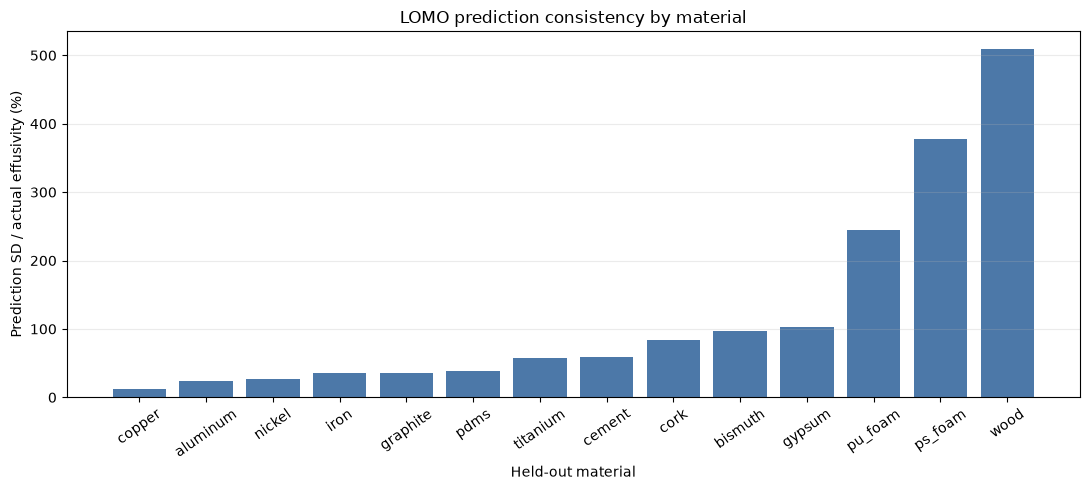

In [38]:
consistency_for_plot = MATERIAL_CONSISTENCY.sort_values(
    "std_over_actual_pct"
)

figure, axis = plt.subplots(figsize=(11, 5))
axis.bar(
    consistency_for_plot["material"],
    consistency_for_plot["std_over_actual_pct"],
    color="#4c78a8",
)
axis.set_title("LOMO prediction consistency by material")
axis.set_xlabel("Held-out material")
axis.set_ylabel("Prediction SD / actual effusivity (%)")
axis.tick_params(axis="x", rotation=35)
axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [39]:
output_files = {
    "search_history": RESULTS_DIR / f"{RESULT_STEM}_search_history.csv",
    "fold_metrics": RESULTS_DIR / f"{RESULT_STEM}_fold_metrics.csv",
    "oof_predictions": RESULTS_DIR / f"{RESULT_STEM}_oof_predictions.csv",
    "pooled_metrics": RESULTS_DIR / f"{RESULT_STEM}_pooled_metrics.csv",
    "fold_stability": RESULTS_DIR / f"{RESULT_STEM}_fold_stability.csv",
    "temperature_metrics": RESULTS_DIR / f"{RESULT_STEM}_temperature_metrics.csv",
    "material_consistency": RESULTS_DIR / f"{RESULT_STEM}_material_prediction_consistency.csv",
}

SEARCH_HISTORY.to_csv(output_files["search_history"], index=False)
FOLD_METRICS.to_csv(output_files["fold_metrics"], index=False)
OOF_PREDICTIONS.to_csv(output_files["oof_predictions"], index=False)
POOLED_METRICS.to_csv(output_files["pooled_metrics"], index=False)
FOLD_STABILITY.to_csv(output_files["fold_stability"], index=False)
TEMPERATURE_METRICS.to_csv(output_files["temperature_metrics"], index=False)
MATERIAL_CONSISTENCY.to_csv(output_files["material_consistency"], index=False)

parameter_payload = {
    "source": "4Av6 beginner-friendly implementation matching the current 4Av5 pipeline",
    "temperature_folders": list(TEMPERATURE_FOLDERS),
    "target": TARGET,
    "analysis_window": list(ANALYSIS_WINDOW),
    "reservoir_seeds": list(RESERVOIR_SEEDS),
    "input_preprocessing": (
        "direct absolute Savitzky-Golay-smoothed Primary and dPrimary/dt; "
        "no baseline centering, minmax scaling, or fitted StandardScaler"
    ),
    "esn_input_channels": ["Primary", "dPrimary/dt"],
    "regressor_inputs": (
        "nine summaries per ESN unit + 27 scalar thermal features + Temperature_C"
    ),
    "summary_features": list(SUMMARY_NAMES),
    "thermal_feature_names": list(THERMAL_COLUMNS),
    "prediction_consistency_metrics": {
        "scope": "per held-out material across all temperatures and repetitions",
        "variance": "sample variance of LOMO predictions (ddof=1)",
        "std": "sample standard deviation of LOMO predictions",
        "normalized_variance": "prediction variance divided by actual target squared",
        "normalized_std": "prediction standard deviation divided by absolute actual target",
    },
    "esn_parameters": BEST_ESN_PARAMETERS,
    "xgb_parameters": BEST_XGB_PARAMETERS,
    "selection_metrics": {
        "objective_J": SUMMARY["performance_index"],
        "pooled_nrmse_range": SUMMARY["nrmse_range"],
        "pooled_r2": SUMMARY["r2"],
        "prediction_range_coverage": SUMMARY["prediction_range_coverage"],
        "sd_fold_nrmse_training_range": SUMMARY["sd_fold_nrmse_training_range"],
    },
    "optuna": {
        "sampler": "multivariate TPESampler",
        "n_trials": N_TRIALS,
        "n_startup_trials": N_STARTUP_TRIALS,
        "optimizer_seed": OPTUNA_SEED,
        "stability_weight": STABILITY_WEIGHT,
        "esn_search_space": ESN_SEARCH_SPACE,
        "xgb_search_space": XGB_SEARCH_SPACE,
    },
    "mlflow": {
        "tracking_uri": MLFLOW_TRACKING_URI,
        "experiment": MLFLOW_EXPERIMENT,
        "parent_run_id": PARENT_RUN_ID,
    },
}

with PARAMETER_FILE.open("w") as parameter_file:
    json.dump(parameter_payload, parameter_file, indent=2)

with mlflow.start_run(run_id=PARENT_RUN_ID):
    for output_path in output_files.values():
        mlflow.log_artifact(str(output_path), artifact_path="best_trial_outputs")
    mlflow.log_artifact(str(PARAMETER_FILE), artifact_path="best_trial_outputs")

print("Saved parameter handoff:", PARAMETER_FILE)
print("MLflow command:")
print(f'mlflow ui --backend-store-uri "{MLFLOW_TRACKING_URI}"')


Saved parameter handoff: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/multi_temp_esn/30C-40C-50C-60C_eff_4av6_beginner_primary_dprimary_absolute_smoothed_0to3_summarized_esn_thermal_optuna_tpe_mlflow_parameters.json
MLflow command:
mlflow ui --backend-store-uri "sqlite:////Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/multi_temp_esn/4Av6_beginner_mlflow_tracking.db"


## Complete variable flow

```text
Settings and paths
    ↓
CSV files → DATA                         many rows per trial
    ↓
contact detection → ALIGNED_TRIALS       one time-series table per trial
    ↓
thermal calculations → THERMAL_FEATURES one feature row per trial
    ↓
Optuna candidate → Reservoir
    ↓
P + dP/dt → state matrix                time × reservoir units
    ↓
nine summaries per unit                 one ESN feature row per trial
    ↓
ESN summaries + 27 thermal + temperature
    ↓
XGBoost → held-out-material predictions
    ↓
14 folds × 3 reservoir seeds → pooled OOF metrics
    ↓
Optuna compares J and proposes the next candidate
```

Important: the expanded code is intended to be easier to trace, not computationally faster.